<a href="https://colab.research.google.com/github/parshverma/AI-CNN-Fairness-Skin-Cancer-Diagnosis/blob/cnn-balanced-dataset/cnn_balanced_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_24 (Conv2D)                   │ (None, 148, 148, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_24 (MaxPooling2D)      │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_25 (Conv2D)                   │ (None, 72, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_25 (MaxPooling2D)      │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_26 (Conv2D)                   │ (None, 34, 34, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_26 (MaxPooling2D)      │ (None, 17, 17, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_8 (Flatten)                  │ (None, 36992)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_16 (Dense)                     │ (None, 128)                 │       4,735,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_17 (Dense)                     │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

🔍 Scanning and cleaning /content/drive/MyDrive/Colab Notebooks/Dataset/gender_groups/male
✅ Cleanup done. Removed 0 problematic images.

Found 156 images belonging to 2 classes.
Found 39 images belonging to 2 classes.
Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.6118 - loss: 1.1463 - val_accuracy: 0.4872 - val_loss: 0.6907
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.5296 - loss: 0.8487 - val_accuracy: 0.5128 - val_loss: 0.7131
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.5636 - loss: 0.6832 - val_accuracy: 0.4872 - val_loss: 0.6744
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.5901 - loss: 0.6666 - val_accuracy: 0.7179 - val_loss: 0.6353
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.6984 - loss: 0.6278 - val_accuracy: 0.7179 - val_loss: 0.5887
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.7682 - loss: 0.5131 - val_accuracy: 0.7436 - val_loss: 0.5367
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 11s

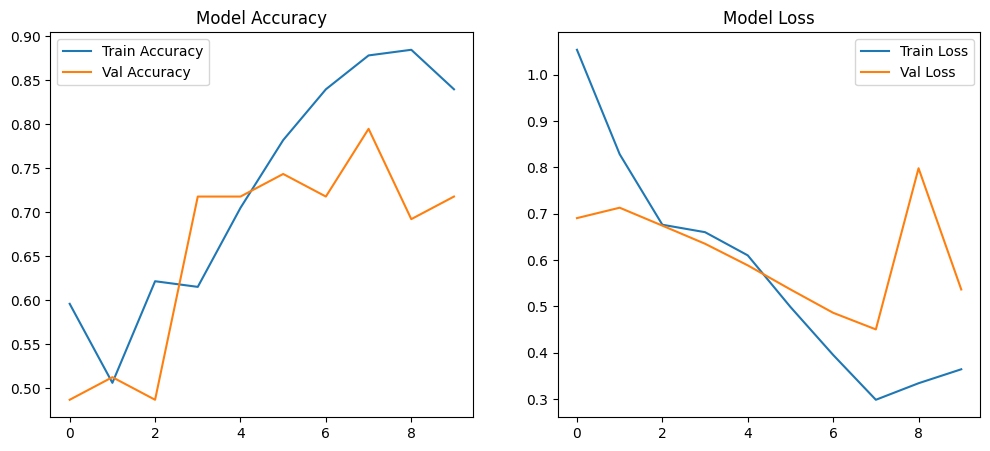

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from google.colab import drive

# Step 1: Mount Google Drive
drive.mount('/content/drive')

# Step 2: Choose dataset group and subgroup
# 👇 Uncomment the one you want to test

# Age groups
# data_path = "/content/drive/MyDrive/Colab Notebooks/Dataset/age_groups/young"
# data_path = "/content/drive/MyDrive/Colab Notebooks/Dataset/age_groups/middle"
# data_path = "/content/drive/MyDrive/Colab Notebooks/Dataset/age_groups/old"

# Gender groups
data_path = "/content/drive/MyDrive/Colab Notebooks/Dataset/gender_groups/male"
# data_path = "/content/drive/MyDrive/Colab Notebooks/Dataset/gender_groups/female"

# Skin tone groups
# data_path = "/content/drive/MyDrive/Colab Notebooks/Dataset/skin_tone/medium"  # ← Example

# Step 3: Image settings
img_size = (150, 150)
batch_size = 32

# Step 4: Data generators (with 20% validation split)
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# train_gen = datagen.flow_from_directory(
#     data_path,
#     target_size=img_size,
#     batch_size=batch_size,
#     class_mode='binary',
#     subset='training'
# )

# val_gen = datagen.flow_from_directory(
#     data_path,
#     target_size=img_size,
#     batch_size=batch_size,
#     class_mode='binary',
#     subset='validation'
# )

# Step 5: CNN model
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')  # Binary output
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

from PIL import Image, UnidentifiedImageError
from PIL.Image import DecompressionBombError

def force_remove_bomb_images(directory, max_pixels=178956970):
    print(f"🔍 Scanning and cleaning {directory}")
    count = 0

    for root, _, files in os.walk(directory):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                img_path = os.path.join(root, file)
                try:
                    with Image.open(img_path) as img:
                        if img.size[0] * img.size[1] > max_pixels:
                            os.remove(img_path)
                            count += 1
                            print(f"⚠️ Removed large image: {file}")
                except DecompressionBombError:
                    os.remove(img_path)
                    count += 1
                    print(f"⚠️ Force-removed bomb image: {file}")
                except UnidentifiedImageError:
                    os.remove(img_path)
                    count += 1
                    print(f"⚠️ Removed unreadable/corrupt image: {file}")
                except Exception as e:
                    print(f"❌ Unexpected error with {file}: {e}")

    print(f"✅ Cleanup done. Removed {count} problematic images.\n")

# force_remove_bomb_images(data_path)

# THEN initialize the generators
train_gen = datagen.flow_from_directory(
    data_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='training'
)

val_gen = datagen.flow_from_directory(
    data_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='validation'
)

# Step 6: Train model
history = model.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen
)

# Step 7: Evaluate performance
val_gen.reset()
y_pred = (model.predict(val_gen) > 0.5).astype("int32").ravel()
y_true = val_gen.classes

print("\n📊 Classification Report:")
print(classification_report(y_true, y_pred, target_names=["Benign", "Malignant"]))

print("\n🧮 Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

# Step 8: Plot training history
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.legend()
plt.title("Model Accuracy")

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Model Loss")
plt.show()


In [ ]:
import os
import shutil

# Define original demographic group folders
base_path = "/content/drive/My Drive/Colab Notebooks/Dataset"
group_folders = {
    "age_groups": ["young", "middle", "old"],
    "gender_groups": ["male", "female"],
    "skin_tone": ["light", "medium", "dark"]
}

# New combined folder path
combined_path = os.path.join(base_path, "all_balanced_structured")

# Create the combined folder structure
for group, subgroups in group_folders.items():
    for subgroup in subgroups:
        for label in ["benign", "malignant"]:
            new_dir = os.path.join(combined_path, group, subgroup, label)
            os.makedirs(new_dir, exist_ok=True)

            # Source directory to copy from
            source_dir = os.path.join(base_path, group, subgroup, label)
            if os.path.exists(source_dir):
                files = os.listdir(source_dir)
                # Limit to 100 images
                for i, file in enumerate(files):
                    if i >= 100:
                        break
                    src_file = os.path.join(source_dir, file)
                    dst_file = os.path.join(new_dir, file)
                    shutil.copy2(src_file, dst_file)

import pandas as pd
summary = []

# Collect summary of copied files
for group, subgroups in group_folders.items():
    for subgroup in subgroups:
        for label in ["benign", "malignant"]:
            path = os.path.join(combined_path, group, subgroup, label)
            count = len(os.listdir(path)) if os.path.exists(path) else 0
            summary.append({"Group": group, "Subgroup": subgroup, "Label": label, "Image Count": count})

df_summary = pd.DataFrame(summary)


KeyboardInterrupt: 

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

🚀 Training on age_groups / young
🔍 Scanning and cleaning /content/drive/My Drive/Colab Notebooks/Dataset/all_balanced_structured/age_groups/young
✅ Cleanup done. Removed 0 problematic images.

Found 160 images belonging to 2 classes.
Found 40 images belonging to 2 classes.


Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_54 (Conv2D)                   │ (None, 148, 148, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_54 (MaxPooling2D)      │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_55 (Conv2D)                   │ (None, 72, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_55 (MaxPooling2D)      │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_56 (Conv2D)                   │ (None, 34, 34, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_56 (MaxPooling2D)      │ (None, 17, 17, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_18 (Flatten)                 │ (None, 36992)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_36 (Dense)                     │ (None, 128)                 │       4,735,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_18 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_37 (Dense)                     │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.4365 - loss: 1.4328 - val_accuracy: 0.5750 - val_loss: 0.6847
Epoch 2/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.6191 - loss: 0.6844 - val_accuracy: 0.5000 - val_loss: 0.6763
Epoch 3/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 18s 4s/step - accuracy: 0.5786 - loss: 0.6587 - val_accuracy: 0.5000 - val_loss: 0.7717
Epoch 4/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.5199 - loss: 0.7192 - val_accuracy: 0.5500 - val_loss: 0.6594
Epoch 5/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.6281 - loss: 0.6150 - val_accuracy: 0.7250 - val_loss: 0.5722
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 180ms/step

📊 Classification Report:
              precision    recall  f1-score   support

      Benign       0.48      0.75      0.59        20
   Malignant       0.44      0.20      0.28        20

    accuracy                           0.47        40
   macro avg       0.46      0.47      0.43        40
weighted avg       0.46      0.47      0.43     

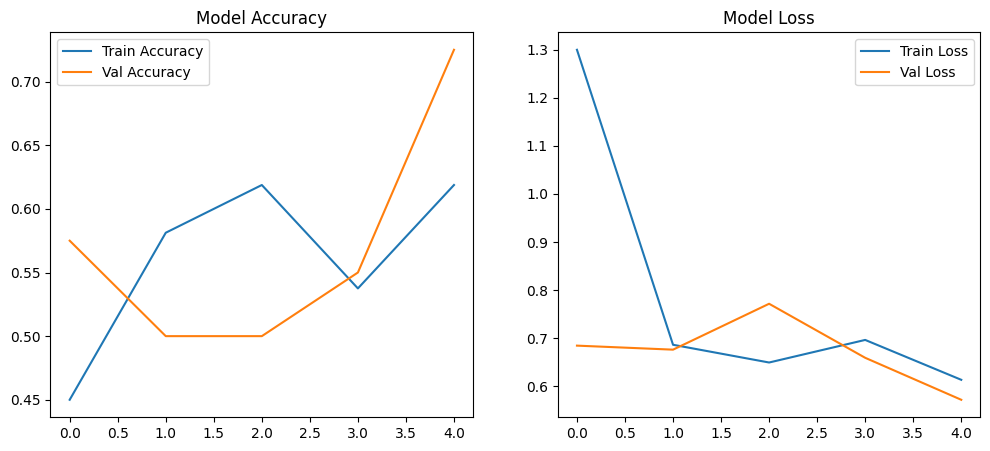


🚀 Training on age_groups / middle
🔍 Scanning and cleaning /content/drive/My Drive/Colab Notebooks/Dataset/all_balanced_structured/age_groups/middle
✅ Cleanup done. Removed 0 problematic images.

Found 160 images belonging to 2 classes.
Found 40 images belonging to 2 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_57 (Conv2D)                   │ (None, 148, 148, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_57 (MaxPooling2D)      │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_58 (Conv2D)                   │ (None, 72, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_58 (MaxPooling2D)      │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_59 (Conv2D)                   │ (None, 34, 34, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_59 (MaxPooling2D)      │ (None, 17, 17, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_19 (Flatten)                 │ (None, 36992)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_38 (Dense)                     │ (None, 128)                 │       4,735,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_19 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_39 (Dense)                     │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.4504 - loss: 0.8634 - val_accuracy: 0.5750 - val_loss: 0.6889
Epoch 2/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.5723 - loss: 0.7018 - val_accuracy: 0.6750 - val_loss: 0.6747
Epoch 3/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.5142 - loss: 0.6862 - val_accuracy: 0.7750 - val_loss: 0.6193
Epoch 4/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.7220 - loss: 0.6266 - val_accuracy: 0.7250 - val_loss: 0.5703
Epoch 5/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.7148 - loss: 0.5828 - val_accuracy: 0.7250 - val_loss: 0.5351
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 165ms/step

📊 Classification Report:
              precision    recall  f1-score   support

      Benign       0.45      0.70      0.55        20
   Malignant       0.33      0.15      0.21        20

    accuracy                           0.42        40
   macro avg       0.39      0.42      0.38        40
weighted avg       0.39      0.42      0.38      

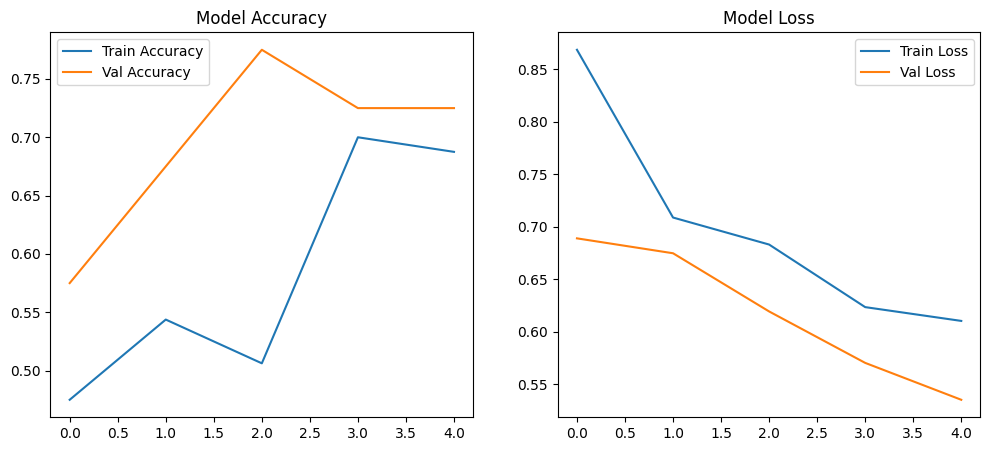


🚀 Training on age_groups / old
🔍 Scanning and cleaning /content/drive/My Drive/Colab Notebooks/Dataset/all_balanced_structured/age_groups/old
✅ Cleanup done. Removed 0 problematic images.

Found 160 images belonging to 2 classes.
Found 40 images belonging to 2 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_60 (Conv2D)                   │ (None, 148, 148, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_60 (MaxPooling2D)      │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_61 (Conv2D)                   │ (None, 72, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_61 (MaxPooling2D)      │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_62 (Conv2D)                   │ (None, 34, 34, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_62 (MaxPooling2D)      │ (None, 17, 17, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_20 (Flatten)                 │ (None, 36992)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_40 (Dense)                     │ (None, 128)                 │       4,735,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_20 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_41 (Dense)                     │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.6266 - loss: 1.3735 - val_accuracy: 0.5000 - val_loss: 0.7704
Epoch 2/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.4676 - loss: 0.7832 - val_accuracy: 0.5000 - val_loss: 0.6900
Epoch 3/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.5299 - loss: 0.6875 - val_accuracy: 0.6000 - val_loss: 0.6753
Epoch 4/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.6019 - loss: 0.6698 - val_accuracy: 0.5000 - val_loss: 0.6754
Epoch 5/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.6140 - loss: 0.6672 - val_accuracy: 0.5000 - val_loss: 0.6481
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 250ms/step

📊 Classification Report:
              precision    recall  f1-score   support

      Benign       0.00      0.00      0.00        20
   Malignant       0.50      1.00      0.67        20

    accuracy                           0.50        40
   macro avg       0.25      0.50      0.33        40
weighted avg       0.25      0.50      0.33      

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


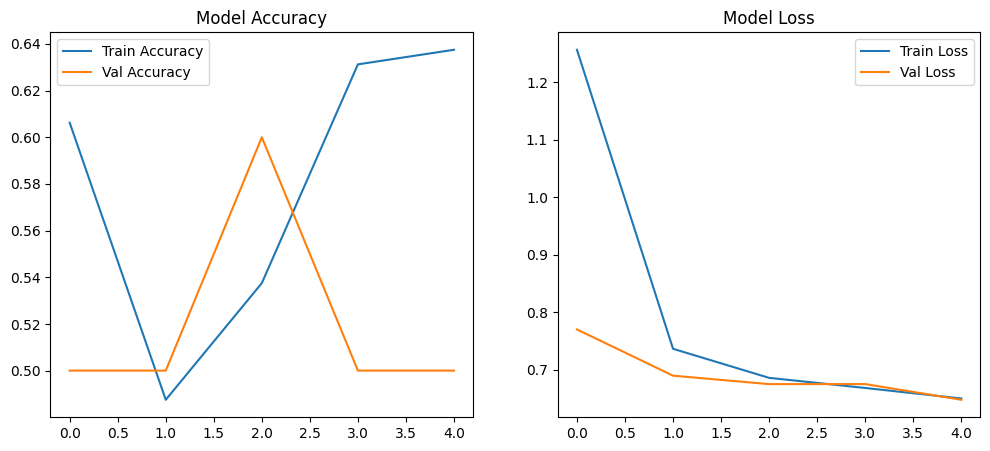


🚀 Training on gender_groups / male
🔍 Scanning and cleaning /content/drive/My Drive/Colab Notebooks/Dataset/all_balanced_structured/gender_groups/male
✅ Cleanup done. Removed 0 problematic images.

Found 156 images belonging to 2 classes.
Found 39 images belonging to 2 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_63 (Conv2D)                   │ (None, 148, 148, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_63 (MaxPooling2D)      │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_64 (Conv2D)                   │ (None, 72, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_64 (MaxPooling2D)      │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_65 (Conv2D)                   │ (None, 34, 34, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_65 (MaxPooling2D)      │ (None, 17, 17, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_21 (Flatten)                 │ (None, 36992)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_42 (Dense)                     │ (None, 128)                 │       4,735,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_21 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_43 (Dense)                     │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.4291 - loss: 0.8841 - val_accuracy: 0.5897 - val_loss: 0.6858
Epoch 2/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.5948 - loss: 0.6879 - val_accuracy: 0.7949 - val_loss: 0.6754
Epoch 3/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.6922 - loss: 0.6723 - val_accuracy: 0.5128 - val_loss: 0.6332
Epoch 4/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.5571 - loss: 0.6366 - val_accuracy: 0.8205 - val_loss: 0.5891
Epoch 5/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.6511 - loss: 0.6048 - val_accuracy: 0.5128 - val_loss: 0.6370
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 266ms/step

📊 Classification Report:
              precision    recall  f1-score   support

      Benign       1.00      0.05      0.10        20
   Malignant       0.50      1.00      0.67        19

    accuracy                           0.51        39
   macro avg       0.75      0.53      0.38        39
weighted avg       0.76      0.51      0.37       

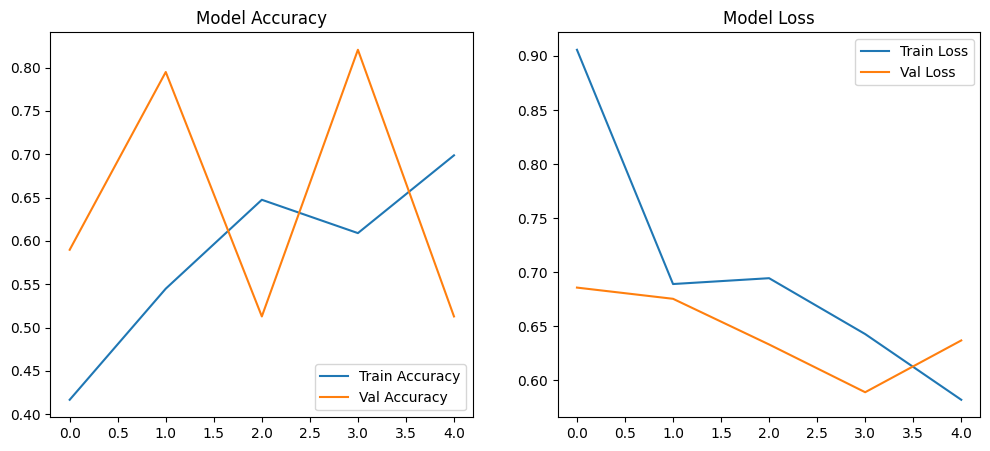


🚀 Training on gender_groups / female
🔍 Scanning and cleaning /content/drive/My Drive/Colab Notebooks/Dataset/all_balanced_structured/gender_groups/female
✅ Cleanup done. Removed 0 problematic images.

Found 160 images belonging to 2 classes.
Found 39 images belonging to 2 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_66 (Conv2D)                   │ (None, 148, 148, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_66 (MaxPooling2D)      │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_67 (Conv2D)                   │ (None, 72, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_67 (MaxPooling2D)      │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_68 (Conv2D)                   │ (None, 34, 34, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_68 (MaxPooling2D)      │ (None, 17, 17, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_22 (Flatten)                 │ (None, 36992)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_44 (Dense)                     │ (None, 128)                 │       4,735,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_22 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_45 (Dense)                     │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.5816 - loss: 1.0671 - val_accuracy: 0.4872 - val_loss: 0.6993
Epoch 2/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.5598 - loss: 0.6985 - val_accuracy: 0.4872 - val_loss: 0.6705
Epoch 3/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.5086 - loss: 0.6858 - val_accuracy: 0.7179 - val_loss: 0.6258
Epoch 4/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.6286 - loss: 0.6259 - val_accuracy: 0.7949 - val_loss: 0.5498
Epoch 5/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.7493 - loss: 0.5490 - val_accuracy: 0.5897 - val_loss: 0.6705
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 165ms/step

📊 Classification Report:
              precision    recall  f1-score   support

      Benign       0.53      0.95      0.68        20
   Malignant       0.67      0.11      0.18        19

    accuracy                           0.54        39
   macro avg       0.60      0.53      0.43        39
weighted avg       0.60      0.54      0.44      

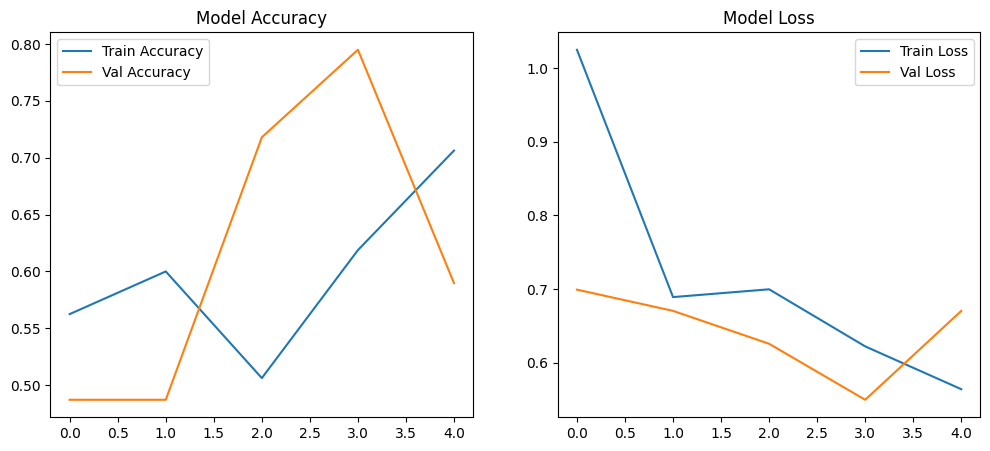


🚀 Training on skin_tone / light
🔍 Scanning and cleaning /content/drive/My Drive/Colab Notebooks/Dataset/all_balanced_structured/skin_tone/light
✅ Cleanup done. Removed 0 problematic images.

Found 160 images belonging to 2 classes.
Found 40 images belonging to 2 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_69 (Conv2D)                   │ (None, 148, 148, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_69 (MaxPooling2D)      │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_70 (Conv2D)                   │ (None, 72, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_70 (MaxPooling2D)      │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_71 (Conv2D)                   │ (None, 34, 34, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_71 (MaxPooling2D)      │ (None, 17, 17, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_23 (Flatten)                 │ (None, 36992)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_46 (Dense)                     │ (None, 128)                 │       4,735,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_23 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_47 (Dense)                     │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 18s 3s/step - accuracy: 0.4497 - loss: 1.5246 - val_accuracy: 0.5000 - val_loss: 0.6903
Epoch 2/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 19s 3s/step - accuracy: 0.4780 - loss: 0.7018 - val_accuracy: 0.5000 - val_loss: 0.6798
Epoch 3/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - accuracy: 0.5023 - loss: 0.7260 - val_accuracy: 0.8000 - val_loss: 0.6201
Epoch 4/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.6545 - loss: 0.6494 - val_accuracy: 0.7250 - val_loss: 0.5820
Epoch 5/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.6602 - loss: 0.6205 - val_accuracy: 0.7000 - val_loss: 0.5576
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 169ms/step

📊 Classification Report:
              precision    recall  f1-score   support

      Benign       0.47      0.75      0.58        20
   Malignant       0.38      0.15      0.21        20

    accuracy                           0.45        40
   macro avg       0.42      0.45      0.40        40
weighted avg       0.42      0.45      0.40     

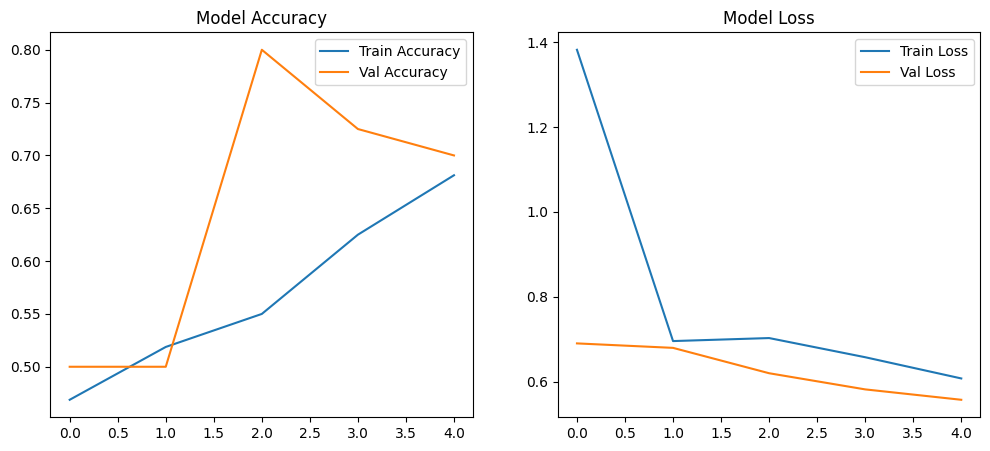


🚀 Training on skin_tone / medium
🔍 Scanning and cleaning /content/drive/My Drive/Colab Notebooks/Dataset/all_balanced_structured/skin_tone/medium
✅ Cleanup done. Removed 0 problematic images.

Found 160 images belonging to 2 classes.
Found 40 images belonging to 2 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_72 (Conv2D)                   │ (None, 148, 148, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_72 (MaxPooling2D)      │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_73 (Conv2D)                   │ (None, 72, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_73 (MaxPooling2D)      │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_74 (Conv2D)                   │ (None, 34, 34, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_74 (MaxPooling2D)      │ (None, 17, 17, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_24 (Flatten)                 │ (None, 36992)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_48 (Dense)                     │ (None, 128)                 │       4,735,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_24 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_49 (Dense)                     │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 16s 3s/step - accuracy: 0.5058 - loss: 1.0964 - val_accuracy: 0.5000 - val_loss: 0.6952
Epoch 2/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.4901 - loss: 0.6982 - val_accuracy: 0.5000 - val_loss: 0.6775
Epoch 3/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.5891 - loss: 0.6692 - val_accuracy: 0.5000 - val_loss: 0.7118
Epoch 4/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.5157 - loss: 0.7065 - val_accuracy: 0.5000 - val_loss: 0.6391
Epoch 5/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.6087 - loss: 0.6310 - val_accuracy: 0.8000 - val_loss: 0.5581
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 304ms/step

📊 Classification Report:
              precision    recall  f1-score   support

      Benign       0.56      0.50      0.53        20
   Malignant       0.55      0.60      0.57        20

    accuracy                           0.55        40
   macro avg       0.55      0.55      0.55        40
weighted avg       0.55      0.55      0.55     

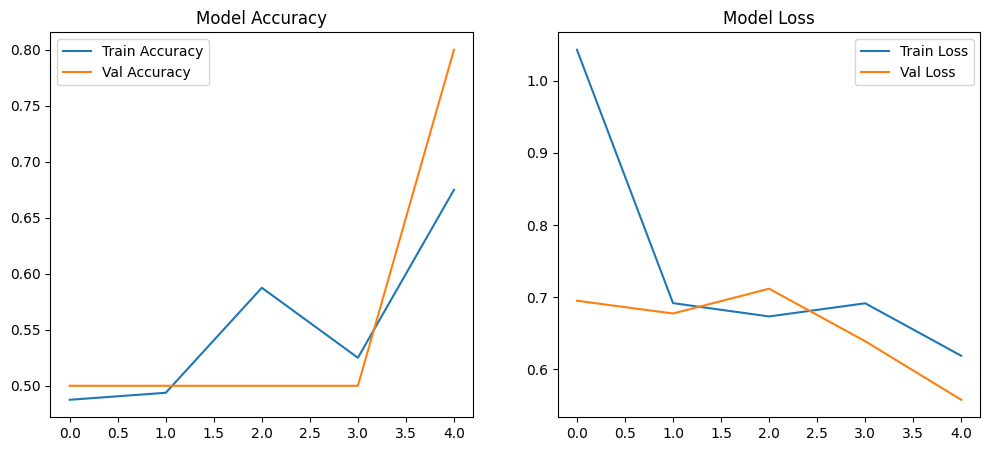


🚀 Training on skin_tone / dark
🔍 Scanning and cleaning /content/drive/My Drive/Colab Notebooks/Dataset/all_balanced_structured/skin_tone/dark
✅ Cleanup done. Removed 0 problematic images.

Found 108 images belonging to 2 classes.
Found 26 images belonging to 2 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_75 (Conv2D)                   │ (None, 148, 148, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_75 (MaxPooling2D)      │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_76 (Conv2D)                   │ (None, 72, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_76 (MaxPooling2D)      │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_77 (Conv2D)                   │ (None, 34, 34, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_77 (MaxPooling2D)      │ (None, 17, 17, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_25 (Flatten)                 │ (None, 36992)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_50 (Dense)                     │ (None, 128)                 │       4,735,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_25 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_51 (Dense)                     │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step - accuracy: 0.6373 - loss: 0.8275 - val_accuracy: 0.7308 - val_loss: 0.5822
Epoch 2/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.7484 - loss: 0.5684 - val_accuracy: 0.7308 - val_loss: 0.5697
Epoch 3/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.7274 - loss: 0.5525 - val_accuracy: 0.7308 - val_loss: 0.6235
Epoch 4/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.7106 - loss: 0.5641 - val_accuracy: 0.7308 - val_loss: 0.6182
Epoch 5/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.7180 - loss: 0.6060 - val_accuracy: 0.5385 - val_loss: 0.6486
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 926ms/step

📊 Classification Report:
              precision    recall  f1-score   support

      Benign       0.76      0.68      0.72        19
   Malignant       0.33      0.43      0.38         7

    accuracy                           0.62        26
   macro avg       0.55      0.56      0.55        26
weighted avg       0.65      0.62      0.63        

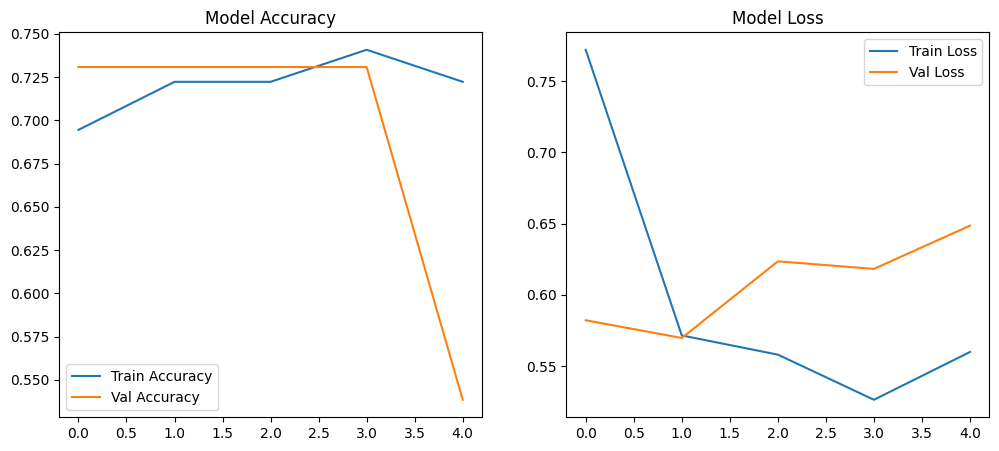

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from google.colab import drive
from PIL import Image, UnidentifiedImageError
from PIL.Image import DecompressionBombError

# Step 1: Mount Google Drive
drive.mount('/content/drive')

# Step 2: Set base dataset path
base_path = "/content/drive/My Drive/Colab Notebooks/Dataset/all_balanced_structured"

# Step 3: Remove oversized or corrupted images
def force_remove_bomb_images(directory, max_pixels=178956970):
    print(f"🔍 Scanning and cleaning {directory}")
    count = 0
    for root, _, files in os.walk(directory):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                img_path = os.path.join(root, file)
                try:
                    with Image.open(img_path) as img:
                        if img.size[0] * img.size[1] > max_pixels:
                            os.remove(img_path)
                            count += 1
                            print(f"⚠️ Removed large image: {file}")
                except (DecompressionBombError, UnidentifiedImageError):
                    os.remove(img_path)
                    count += 1
                    print(f"⚠️ Removed bad image: {file}")
    print(f"✅ Cleanup done. Removed {count} problematic images.\n")

# Step 4: Training function
def train_on_dataset(data_path):
    force_remove_bomb_images(data_path)

    img_size = (150, 150)
    batch_size = 32

    datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

    train_gen = datagen.flow_from_directory(
        data_path,
        target_size=img_size,
        batch_size=batch_size,
        class_mode='binary',
        subset='training'
    )

    val_gen = datagen.flow_from_directory(
        data_path,
        target_size=img_size,
        batch_size=batch_size,
        class_mode='binary',
        subset='validation'
    )

    model = Sequential([
        Conv2D(32, (3,3), activation='relu', input_shape=(150, 150, 3)),
        MaxPooling2D(2,2),
        Conv2D(64, (3,3), activation='relu'),
        MaxPooling2D(2,2),
        Conv2D(128, (3,3), activation='relu'),
        MaxPooling2D(2,2),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    model.summary()

    history = model.fit(train_gen, epochs=5, validation_data=val_gen)

    val_gen.reset()
    y_pred = (model.predict(val_gen) > 0.5).astype("int32").ravel()
    y_true = val_gen.classes

    print("\n📊 Classification Report:")
    print(classification_report(y_true, y_pred, target_names=["Benign", "Malignant"]))

    print("\n🧮 Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="Train Accuracy")
    plt.plot(history.history["val_accuracy"], label="Val Accuracy")
    plt.legend()
    plt.title("Model Accuracy")

    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Val Loss")
    plt.legend()
    plt.title("Model Loss")
    plt.show()

# Step 5: Loop through all subgroups
for group in os.listdir(base_path):
    group_path = os.path.join(base_path, group)
    if os.path.isdir(group_path):
        for subgroup in os.listdir(group_path):
            current_path = os.path.join(group_path, subgroup)
            print(f"\n🚀 Training on {group} / {subgroup}")
            train_on_dataset(current_path)

In [ ]:
import numpy as np

def demographic_parity(y_pred, group_labels):
    """Checks if positive prediction rates are similar across groups."""
    rates = {}
    for group in np.unique(group_labels):
        group_indices = (group_labels == group)
        rates[group] = np.mean(y_pred[group_indices])
    return rates

def equal_opportunity(y_true, y_pred, group_labels):
    """Checks true positive rates across groups."""
    tpr = {}
    for group in np.unique(group_labels):
        group_indices = (group_labels == group) & (y_true == 1)
        if np.sum(group_indices) == 0:
            tpr[group] = np.nan  # Avoid division by zero
        else:
            tpr[group] = np.mean(y_pred[group_indices])
    return tpr

def disparate_impact(y_pred, group_labels):
    """Compares selection rate of unprivileged vs privileged groups."""
    groups = list(np.unique(group_labels))
    if len(groups) != 2:
        return "Disparate Impact is best used for binary subgroups."
    g1, g2 = groups
    rate1 = np.mean(y_pred[group_labels == g1])
    rate2 = np.mean(y_pred[group_labels == g2])
    return rate1 / rate2 if rate2 > 0 else np.nan


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Replace with your path
test_path = "/content/drive/MyDrive/Colab Notebooks/Dataset/all_balanced_structured/gender_groups"

img_size = (150, 150)
batch_size = 32

datagen = ImageDataGenerator(rescale=1./255)

test_gen = datagen.flow_from_directory(
    test_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)

# Make predictions
y_pred_probs = model.predict(test_gen)
y_pred = (y_pred_probs > 0.5).astype("int32").ravel()
y_true = test_gen.classes

# Group labels (gender from folder names)
group_labels = np.array([path.split('/')[-2] for path in test_gen.filepaths])

# Compute metrics
dp = demographic_parity(y_pred, group_labels)
eo = equal_opportunity(y_true, y_pred, group_labels)
di = disparate_impact(y_pred, group_labels)

print("📊 Demographic Parity:", dp)
print("🎯 Equal Opportunity:", eo)
print("⚖️ Disparate Impact:", di)


Found 394 images belonging to 2 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 676ms/step
📊 Demographic Parity: {np.str_('benign'): np.float64(0.005), np.str_('malignant'): np.float64(0.5567010309278351)}
🎯 Equal Opportunity: {np.str_('benign'): np.float64(0.0), np.str_('malignant'): np.float64(0.6421052631578947)}
⚖️ Disparate Impact: 0.008981481481481481


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 1224 images belonging to 3 classes.
Found 304 images belonging to 3 classes.
⚡ Preloading training data into RAM...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


🚀 Starting optimized training...
Epoch 1/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.3792 - loss: 5.6417

20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 278ms/step - accuracy: 0.3794 - loss: 5.6646 - val_accuracy: 0.2566 - val_loss: 1.2170
Epoch 2/15
17/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2992 - loss: 1.1665

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3049 - loss: 1.1572 - val_accuracy: 0.3257 - val_loss: 1.0976
Epoch 3/15
17/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4231 - loss: 1.0804

...

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4736 - loss: 0.9981 - val_accuracy: 0.4605 - val_loss: 1.0338
Epoch 7/15
17/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4983 - loss: 0.9709

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4953 - loss: 0.9726 - val_accuracy: 0.4704 - val_loss: 0.9930
Epoch 8/15
15/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4835 - loss: 0.9801

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4868 - loss: 0.9770 - val_accuracy: 0.4539 - val_loss: 1.0862
Epoch 9/15
17/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5063 - loss: 0.9701

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5086 - loss: 0.9679 - val_accuracy: 0.4474 - val_loss: 1.0222
Epoch 10/15
17/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5374 - loss: 0.9184

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5380 - loss: 0.9156 - val_accuracy: 0.4704 - val_loss: 1.0952

📊 Final Validation Report:
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 107ms/step
               precision    recall  f1-score   support

   age_groups       0.43      0.79      0.55       120
gender_groups       0.00      0.00      0.00        78
    skin_tone       0.62      0.45      0.52       106

     accuracy                           0.47       304
    macro avg       0.35      0.41      0.36       304
 weighted avg       0.39      0.47      0.40       304


🧮 Confusion Matrix:
[[95  4 21]
 [70  0  8]
 [58  0 48]]


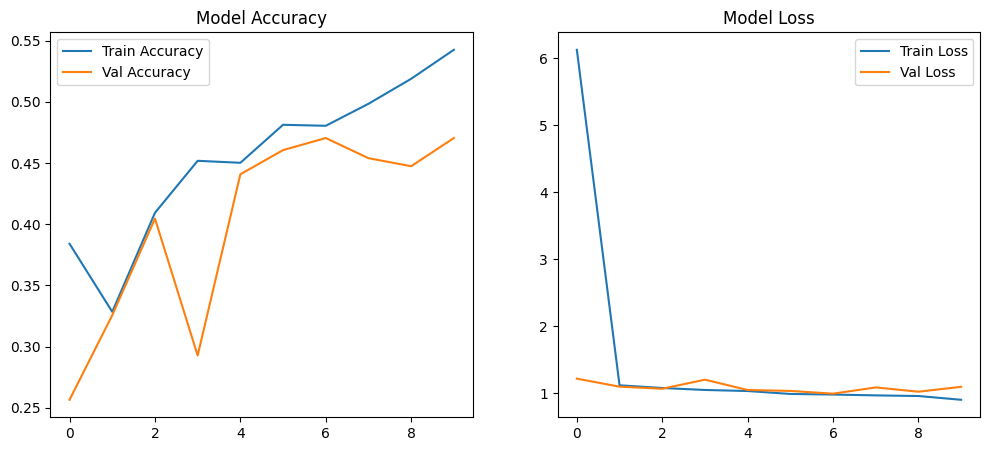

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from google.colab import drive
from PIL import Image, UnidentifiedImageError
from PIL.Image import DecompressionBombError
import tensorflow as tf
from tensorflow.keras import mixed_precision

# ===== ORIGINAL SETUP =====
drive.mount('/content/drive')
data_path = "/content/drive/My Drive/Colab Notebooks/Dataset/all_balanced_structured"

def force_remove_bomb_images(directory, max_pixels=178956970):
    print(f"🔍 Scanning and cleaning {directory}")
    count = 0
    for root, _, files in os.walk(directory):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                img_path = os.path.join(root, file)
                try:
                    with Image.open(img_path) as img:
                        if img.size[0] * img.size[1] > max_pixels:
                            os.remove(img_path)
                            count += 1
                            print(f"⚠️ Removed large image: {file}")
                except (DecompressionBombError, UnidentifiedImageError):
                    os.remove(img_path)
                    count += 1
                    print(f"⚠️ Removed bad image: {file}")
    print(f"✅ Cleanup done. Removed {count} problematic images.\n")

# ===== OPTIMIZED TRAINING CODE =====
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)

gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        tf.config.optimizer.set_jit(True)
    except RuntimeError as e:
        print(e)

IMG_SIZE = (128, 128)
BATCH_SIZE = 64

def preload_images_to_ram(generator):
    """Load all images into RAM for 10x faster training"""
    images, labels = [], []
    for _ in range(len(generator)):
        x, y = next(generator)  # Fixed this line
        images.append(x)
        labels.append(y)
    return np.vstack(images), np.concatenate(labels)

def build_optimized_model(num_classes):
    """Updated for multi-class classification"""
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', input_shape=(*IMG_SIZE, 3)),
        MaxPooling2D(2,2),
        Conv2D(64, (3,3), activation='relu'),
        MaxPooling2D(2,2),
        Flatten(),
        Dense(64, activation='relu'),
        Dense(num_classes, activation='softmax')  # Changed for multi-class
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                 loss='sparse_categorical_crossentropy',  # Updated loss
                 metrics=['accuracy'])
    return model

def train_with_optimizations():
    # force_remove_bomb_images(data_path)

    train_datagen = ImageDataGenerator(
        rescale=1/255.,
        validation_split=0.2,
        preprocessing_function=tf.keras.applications.efficientnet.preprocess_input
    )

    train_gen = train_datagen.flow_from_directory(
        data_path,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='sparse',  # Changed for multi-class
        subset='training'
    )

    val_gen = train_datagen.flow_from_directory(
        data_path,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='sparse',  # Changed for multi-class
        subset='validation'
    )

    print("⚡ Preloading training data into RAM...")
    X_train, y_train = preload_images_to_ram(train_gen)
    X_val, y_val = preload_images_to_ram(val_gen)

    # Get number of classes from generator
    num_classes = len(train_gen.class_indices)
    model = build_optimized_model(num_classes)

    print("🚀 Starting optimized training...")
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=15,
        batch_size=BATCH_SIZE,
        callbacks=[
            tf.keras.callbacks.EarlyStopping(patience=3),
            tf.keras.callbacks.ModelCheckpoint('best_model.h5')
        ]
    )

    # Generate reports
    print("\n📊 Final Validation Report:")
    y_pred = np.argmax(model.predict(X_val), axis=1)  # For multi-class
    print(classification_report(y_val, y_pred, target_names=list(train_gen.class_indices.keys())))
    print("\n🧮 Confusion Matrix:")
    print(confusion_matrix(y_val, y_pred))

    # Plot training history
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="Train Accuracy")
    plt.plot(history.history["val_accuracy"], label="Val Accuracy")
    plt.legend()
    plt.title("Model Accuracy")

    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Val Loss")
    plt.legend()
    plt.title("Model Loss")
    plt.show()

    return model

# Run the optimized training
final_model = train_with_optimizations()